# Linear Regression

Linear Regression is a supervised machine learning algorithm used to predict a continuous numerical target.

Examples of regression problems:

- Predict house price
- Predict salary
- Predict sales
- Predict temperature
- Predict product demand
- Predict delivery time

Linear Regression assumes that the target variable has a linear relationship with one or more input features.

There are two important forms of Linear Regression:

1. Simple Linear Regression
2. Multiple Linear Regression

Simple Linear Regression uses one feature.

Multiple Linear Regression uses two or more features.

## Learning Objectives

In this notebook, we will learn:

- What Linear Regression is
- How Simple Linear Regression works
- How Multiple Linear Regression works
- The mathematical equations
- How predictions are generated
- What residuals/errors are
- What a loss function is
- How Mean Squared Error is calculated
- How the best-fitting line is obtained
- How to train a Linear Regression model using Scikit-Learn
- How to interpret coefficients
- How to evaluate a regression model
- How to analyze residuals
- Important assumptions of Linear Regression
- Advantages and limitations

## 2. What is Linear Regression?

Linear Regression attempts to model the relationship between input variables and a continuous target variable using a linear equation.

The model learns parameters from the training data.

For one feature:

$$
\hat{y} = b_0 + b_1x
$$

Where:

- $x$ = input feature
- $\hat{y}$ = predicted target
- $b_0$ = intercept
- $b_1$ = coefficient/slope

The goal is to find the values of $b_0$ and $b_1$ that produce predictions as close as possible to the actual target values.

## 3. Simple Linear Regression

Simple Linear Regression uses:

- One independent variable
- One continuous dependent variable

For example:

**Feature:**

Years of Experience

**Target:**

Salary

The model can be written as:

$$
\hat{y} = b_0 + b_1x
$$

Suppose the model learns:

$$
b_0 = 25000
$$

and

$$
b_1 = 5000
$$

Then:

$$
\hat{y} = 25000 + 5000x
$$

For 5 years of experience:

$$
\hat{y} = 25000 + 5000(5)
$$

$$
\hat{y} = 50000
$$

Therefore, the predicted salary is $50,000.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [2]:
# Create a simple dataset

experience = np.array([
    1, 2, 3, 4, 5,
    6, 7, 8, 9, 10
])

salary = np.array([
    30000, 35000, 40000, 45000, 50000,
    55000, 60000, 65000, 70000, 75000
])

simple_df = pd.DataFrame({
    "Experience": experience,
    "Salary": salary
})

simple_df

,Experience,Salary
0,1,30000
1,2,35000
2,3,40000
3,4,45000
4,5,50000
5,6,55000
6,7,60000
7,8,65000
8,9,70000
9,10,75000


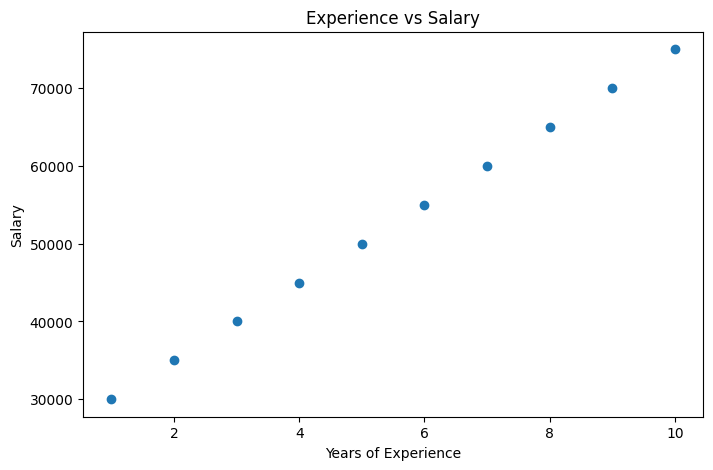

In [3]:
plt.figure(figsize=(8, 5))

plt.scatter(
    simple_df["Experience"],
    simple_df["Salary"]
)

plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Experience vs Salary")

plt.show()

## 4. Mathematical Equation

The equation for Simple Linear Regression is:

$$
\hat{y} = b_0 + b_1x
$$

Here:

### Intercept

$b_0$ is the intercept.

It represents the predicted value of $y$ when $x=0$.

### Coefficient

$b_1$ is the coefficient or slope.

It represents the expected change in $y$ for a one-unit increase in $x$.

For example:

$$
\hat{y} = 25000 + 5000x
$$

The coefficient is:

$$
b_1 = 5000
$$

This means that for every additional year of experience, the predicted salary increases by approximately $5,000.

## 5. Prediction

Once the model has learned $b_0$ and $b_1$, it can generate predictions.

The prediction is:

$$
\hat{y} = b_0 + b_1x
$$

For example:

$$
b_0 = 25000
$$

$$
b_1 = 5000
$$

For:

$$
x = 7
$$

the prediction is:

$$
\hat{y} = 25000 + 5000(7)
$$

$$
\hat{y} = 60000
$$

## 6. Prediction Error and Residual

The prediction will usually not be exactly equal to the actual value.

The difference between the actual value and predicted value is called the residual.

$$
e_i = y_i - \hat{y}_i
$$

Where:

- $y_i$ = actual value
- $\hat{y}_i$ = predicted value
- $e_i$ = residual

For example:

Actual salary:

$$
y = 52000
$$

Predicted salary:

$$
\hat{y} = 50000
$$

Then:

$$
e = 52000 - 50000
$$

$$
e = 2000
$$

A residual can be positive or negative.

## 7. Loss Function

A machine learning model needs a way to measure how wrong its predictions are.

A **loss function** measures the error between actual values and predicted values.

For Linear Regression, a common loss function is Mean Squared Error (MSE).

The Mean Squared Error is:

$$
MSE =
\frac{1}{n}
\sum_{i=1}^{n}
(y_i-\hat{y}_i)^2
$$

Where:

- $n$ = number of observations
- $y_i$ = actual value
- $\hat{y}_i$ = predicted value

The objective is to find model parameters that minimize the loss.

Therefore:

$$
\boxed{
\text{Minimize } MSE
}
$$

The model searches for the line that produces the smallest total squared error.

## 8. Calculating Mean Squared Error

Consider:

Actual values:

$$
y = [10, 20, 30]
$$

Predicted values:

$$
\hat{y} = [12, 18, 33]
$$

Errors:

$$
[-2, 2, -3]
$$

Squared errors:

$$
[4, 4, 9]
$$

Therefore:

$$
MSE = \frac{4+4+9}{3}
$$

$$
MSE = 5.67
$$

In [4]:
# Actual values
y_actual = np.array([10, 20, 30])

# Predicted values
y_predicted = np.array([12, 18, 33])

# Calculate errors
errors = y_actual - y_predicted

# Calculate squared errors
squared_errors = errors ** 2

# Calculate MSE
mse = np.mean(squared_errors)

print("Errors:", errors)
print("Squared Errors:", squared_errors)
print("MSE:", mse)

Errors: [-2  2 -3]
Squared Errors: [4 4 9]
MSE: 5.666666666666667


## 9. Linear Regression Loss Function

For Simple Linear Regression:

$$
\hat{y}_i = b_0 + b_1x_i
$$

Substituting this into MSE:

$$
J(b_0,b_1)
=
\frac{1}{n}
\sum_{i=1}^{n}
\left[
y_i-(b_0+b_1x_i)
\right]^2
$$

This is the objective function that the model wants to minimize.

Different values of $b_0$ and $b_1$ produce different lines.

Each line has a different MSE.

The best-fitting line is the line with the minimum value of the objective function.

## 10. Ordinary Least Squares

A standard method for fitting Linear Regression is called **Ordinary Least Squares (OLS)**.

OLS chooses the model parameters that minimize the sum of squared residuals.

The objective is:

$$
\min
\sum_{i=1}^{n}
(y_i-\hat{y}_i)^2
$$

Since:

$$
\hat{y}_i = b_0+b_1x_i
$$

we obtain:

$$
\min
\sum_{i=1}^{n}
\left[
y_i-(b_0+b_1x_i)
\right]^2
$$

In simple terms:

> OLS finds the line that minimizes the total squared vertical distance between the actual observations and the regression line.

# 11. Multiple Linear Regression

Simple Linear Regression uses only one feature.

However, real-world problems usually have multiple factors affecting the target.

For example, house price may depend on:

- Area
- Number of bedrooms
- Number of bathrooms
- Age of the house
- Distance from city center

Multiple Linear Regression allows us to use multiple features simultaneously.

For $p$ features, the equation is:

$$
\hat{y}
=
b_0
+
b_1x_1
+
b_2x_2
+
\cdots
+
b_px_p
$$

Where:

- $b_0$ = intercept
- $b_1, b_2, ..., b_p$ = coefficients
- $x_1, x_2, ..., x_p$ = features
- $\hat{y}$ = predicted target

## Example of Multiple Linear Regression

Suppose we predict house price using:

- $x_1$ = area
- $x_2$ = number of bedrooms
- $x_3$ = house age

The model could be:

$$
\hat{y}
=
50000
+
200x_1
+
10000x_2
-
1500x_3
$$

Interpretation:

- $50000$ → intercept
- $200$ → effect of area
- $10000$ → effect of one additional bedroom
- $-1500$ → effect of one additional year of age

The coefficients represent the expected change in the target when that feature increases by one unit, **holding the other features constant**.

## 12. Matrix Representation

Multiple Linear Regression can also be represented using matrices.

The equation is:

$$
\hat{y} = Xb
$$

More explicitly:

$$
\begin{bmatrix}
\hat{y}_1 \\
\hat{y}_2 \\
\vdots \\
\hat{y}_n
\end{bmatrix}
=
\begin{bmatrix}
1 & x_{11} & x_{12} & \cdots & x_{1p} \\
1 & x_{21} & x_{22} & \cdots & x_{2p} \\
\vdots & \vdots & \vdots & \ddots & \vdots \\
1 & x_{n1} & x_{n2} & \cdots & x_{np}
\end{bmatrix}
\begin{bmatrix}
b_0 \\
b_1 \\
\vdots \\
b_p
\end{bmatrix}
$$

The first column of $X$ contains ones so that the intercept $b_0$ can be included.

The important idea is:

$$
\boxed{\hat{y}=Xb}
$$

# 13. Practical Example: House Price Prediction

We will now build a Multiple Linear Regression model.

Features:

- Area
- Bedrooms
- Bathrooms
- Age

Target:

- Price

In [5]:
# Create a sample house dataset

house_data = {
    "Area": [800, 1000, 1200, 1500, 1800, 2000, 2200, 2500, 2800, 3000],
    "Bedrooms": [2, 2, 3, 3, 3, 4, 4, 4, 5, 5],
    "Bathrooms": [1, 1, 2, 2, 2, 2, 3, 3, 3, 4],
    "Age": [20, 15, 10, 8, 5, 7, 4, 3, 2, 1],
    "Price": [
        150000, 180000, 230000, 280000, 320000,
        370000, 410000, 470000, 530000, 600000
    ]
}

house_df = pd.DataFrame(house_data)

house_df

,Area,Bedrooms,Bathrooms,Age,Price
0,800,2,1,20,150000
1,1000,2,1,15,180000
2,1200,3,2,10,230000
3,1500,3,2,8,280000
4,1800,3,2,5,320000
5,2000,4,2,7,370000
6,2200,4,3,4,410000
7,2500,4,3,3,470000
8,2800,5,3,2,530000
9,3000,5,4,1,600000


In [6]:
# Check dataset information

house_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Area       10 non-null     int64
 1   Bedrooms   10 non-null     int64
 2   Bathrooms  10 non-null     int64
 3   Age        10 non-null     int64
 4   Price      10 non-null     int64
dtypes: int64(5)
memory usage: 532.0 bytes


In [7]:
# Check basic statistics

house_df.describe()

,Area,Bedrooms,Bathrooms,Age,Price
count,10.000000,10.000000,10.000000,10.000000,10.000000
mean,1880.000000,3.500000,2.300000,7.500000,354000.000000
std,756.894239,1.080123,0.948683,6.059886,149903.672774
min,800.000000,2.000000,1.000000,1.000000,150000.000000
25%,1275.000000,3.000000,2.000000,3.250000,242500.000000
50%,1900.000000,3.500000,2.000000,6.000000,345000.000000
75%,2425.000000,4.000000,3.000000,9.500000,455000.000000
max,3000.000000,5.000000,4.000000,20.000000,600000.000000


In [8]:
# Check missing values

house_df.isnull().sum()

Area         0
Bedrooms     0
Bathrooms    0
Age          0
Price        0
dtype: int64

## 15. Separate Features and Target

Our features are:

$$
X =
[
Area,\ Bedrooms,\ Bathrooms,\ Age
]
$$

Our target is:

$$
y = Price
$$

In [9]:
# Features
X = house_df[
    ["Area", "Bedrooms", "Bathrooms", "Age"]
]

# Target
y = house_df["Price"]

print("Features:")
display(X)

print("Target:")
display(y)

Features:


,Area,Bedrooms,Bathrooms,Age
0,800,2,1,20
1,1000,2,1,15
2,1200,3,2,10
3,1500,3,2,8
4,1800,3,2,5
5,2000,4,2,7
6,2200,4,3,4
7,2500,4,3,3
8,2800,5,3,2
9,3000,5,4,1


Target:


0    150000
1    180000
2    230000
3    280000
4    320000
5    370000
6    410000
7    470000
8    530000
9    600000
Name: Price, dtype: int64

## 16. Train-Test Split

We divide the data into:

### Training Set

Used to learn the model parameters.

### Testing Set

Used to evaluate the model on unseen data.

We will use:

- 80% training data
- 20% testing data

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 8
Testing samples: 2


## 17. Train the Model

We create a Linear Regression model and train it using the training data.

The model will learn:

$$
\hat{y}
=
b_0
+
b_1x_1
+
b_2x_2
+
b_3x_3
+
b_4x_4
$$

where:

- $x_1$ = Area
- $x_2$ = Bedrooms
- $x_3$ = Bathrooms
- $x_4$ = Age

In [11]:
# Create the model

model = LinearRegression()

# Train the model

model.fit(
    X_train,
    y_train
)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## 18. Model Parameters

After training, the model learns:

- One intercept
- One coefficient for each feature

The equation becomes:

$$
\hat{y}
=
b_0
+
b_1Area
+
b_2Bedrooms
+
b_3Bathrooms
+
b_4Age
$$

In [12]:
# Display intercept

print("Intercept:", model.intercept_)

Intercept: -100973.82493667299


In [13]:
# Display coefficients

coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coefficients

,Feature,Coefficient
0,Area,175.616850
1,Bedrooms,10743.034056
2,Bathrooms,27446.289521
3,Age,3125.058636


## 19. Interpreting Coefficients

Suppose the coefficient of Area is:

$$
b_1 = 200
$$

This means:

> For every one-unit increase in Area, the predicted house price increases by approximately 200 units, while keeping the other features constant.

Similarly, if the coefficient of Age is negative:

$$
b_4 < 0
$$

then increasing house age is associated with a decrease in predicted price, holding the other features constant.

This "holding other features constant" condition is important in Multiple Linear Regression.

## 20. Make Predictions

After training, we use the model to predict prices for the test set.

The model calculates:

$$
\hat{y}=Xb
$$

In [14]:
# Predict test values

y_pred = model.predict(X_test)

# Create comparison table

results = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred
})

results

,Actual Price,Predicted Price
0,530000,533057.510085
1,180000,170451.261844


## 21. Calculate the Loss

We can calculate the Mean Squared Error of our predictions.

$$
MSE =
\frac{1}{n}
\sum_{i=1}^{n}
(y_i-\hat{y}_i)^2
$$

The MSE measures the average squared prediction error.

A lower MSE indicates smaller prediction errors.

In [15]:
# Calculate residuals

residuals = y_test - y_pred

# Calculate squared errors

squared_errors = residuals ** 2

# Calculate MSE manually

mse_manual = np.mean(squared_errors)

print("Manual MSE:", mse_manual)

Manual MSE: 50263384.14270098


In [16]:
# Verify using Scikit-Learn

mse = mean_squared_error(
    y_test,
    y_pred
)

print("Scikit-Learn MSE:", mse)

Scikit-Learn MSE: 50263384.14270098


## 22. Regression Evaluation Metrics

### Mean Absolute Error

$$
MAE =
\frac{1}{n}
\sum_{i=1}^{n}
|y_i-\hat{y}_i|
$$

MAE represents the average absolute prediction error.

---

### Mean Squared Error

$$
MSE =
\frac{1}{n}
\sum_{i=1}^{n}
(y_i-\hat{y}_i)^2
$$

MSE penalizes large errors more strongly.

---

### Root Mean Squared Error

$$
RMSE = \sqrt{MSE}
$$

RMSE is in the same unit as the target.

---

### R² Score

$$
R^2 =
1 -
\frac{
\sum(y_i-\hat{y}_i)^2
}{
\sum(y_i-\bar{y})^2
}
$$

R² measures how much of the variation in the target is explained by the model.

In [17]:
# Calculate regression metrics

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 6303.124120461405
MSE : 50263384.14270098
RMSE: 7089.667421163067
R²  : 0.9983587466402384


## 23. Actual vs Predicted Values

A good regression model should produce predictions that are close to the actual values.

We can visualize this by plotting:

- Actual values on the x-axis
- Predicted values on the y-axis

If predictions are perfect, all points would lie on:

$$
y=x
$$

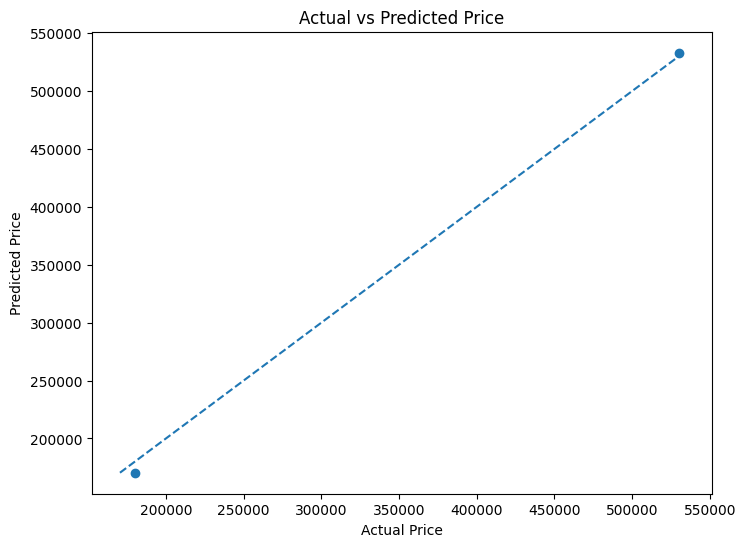

In [18]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred
)

# Perfect prediction line
minimum = min(y_test.min(), y_pred.min())
maximum = max(y_test.max(), y_pred.max())

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price")

plt.show()

## 24. Residual Analysis

Residual:

$$
e_i = y_i-\hat{y}_i
$$

Residual analysis helps us determine whether the model is making systematic errors.

Ideally, residuals should:

- Be centered around zero
- Have no obvious pattern
- Have roughly constant spread

A strong pattern in the residuals may indicate that the linear model is not capturing the underlying relationship properly.

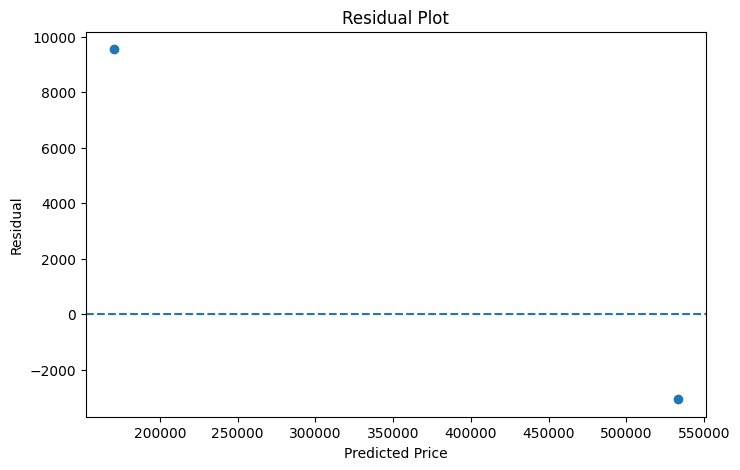

In [19]:
plt.figure(figsize=(8, 5))

plt.scatter(
    y_pred,
    residuals
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Price")
plt.ylabel("Residual")
plt.title("Residual Plot")

plt.show()

## 25. Assumptions of Linear Regression

Linear Regression works best when several assumptions are reasonably satisfied.

### 1. Linearity

The relationship between the features and target should be approximately linear.

### 2. Independence

Observations should generally be independent of each other.

### 3. Homoscedasticity

The variance of residuals should be approximately constant across predicted values.

### 4. No severe multicollinearity

Features should not be extremely correlated with one another.

### 5. Normally distributed residuals

For statistical inference, residuals are often assumed to be approximately normally distributed.

These assumptions are especially important when using Linear Regression for statistical inference and interpretation.

## 26. Multicollinearity

Multicollinearity occurs when two or more input features are strongly correlated.

For example:

- House area
- Number of rooms

may be strongly related.

High multicollinearity can make coefficient estimates unstable and difficult to interpret.

One common diagnostic is the **Variance Inflation Factor (VIF)**.

The basic idea is:

> If features contain highly redundant information, interpreting individual coefficients becomes difficult.

## 27. Feature Scaling

Feature scaling changes features to comparable numerical scales.

For ordinary Linear Regression fitted using OLS, feature scaling is generally **not required for obtaining the basic least-squares solution**.

However, scaling can become useful when:

- Comparing coefficient magnitudes
- Using regularized Linear Regression
- Combining Linear Regression with optimization algorithms such as Gradient Descent

Therefore, we should not automatically scale every Linear Regression dataset without understanding why.

## 28. Simple vs Multiple Linear Regression

| Property | Simple Linear Regression | Multiple Linear Regression |
|---|---|---|
| Number of features | 1 | 2 or more |
| Equation | $\hat{y}=b_0+b_1x$ | $\hat{y}=b_0+b_1x_1+\cdots+b_px_p$ |
| Visualization | Easy in 2D | More difficult |
| Example | Salary from experience | Price from area, rooms, age |
| Interpretation | One coefficient | Multiple coefficients |

Both models are forms of Linear Regression.

## 29. Advantages of Linear Regression

- Simple to understand
- Fast to train
- Easy to interpret
- Works well when relationships are approximately linear
- Provides useful coefficients
- Strong baseline model
- Computationally efficient

## 30. Limitations of Linear Regression

- Assumes a linear relationship
- Sensitive to outliers
- Multicollinearity can make coefficients unstable
- May perform poorly when relationships are strongly nonlinear
- Requires attention to important assumptions
- Coefficient interpretation can become difficult with correlated features

# 31. Complete Linear Regression Workflow

The complete workflow is:

1. Load the dataset
2. Understand the features and target
3. Perform basic data exploration
4. Handle missing values if necessary
5. Separate features $X$ and target $y$
6. Split the data into training and testing sets
7. Create the Linear Regression model
8. Train the model
9. Learn coefficients and intercept
10. Generate predictions
11. Calculate residuals
12. Calculate the loss
13. Evaluate using MAE, MSE, RMSE and R²
14. Visualize predictions
15. Analyze residuals
16. Check important assumptions
17. Interpret the model
18. Use the model to predict new observations

# 32. Summary

Linear Regression is a supervised learning algorithm for predicting continuous numerical values.

### Simple Linear Regression

Uses one feature:

$$
\hat{y}=b_0+b_1x
$$

### Multiple Linear Regression

Uses multiple features:

$$
\hat{y}
=
b_0+b_1x_1+b_2x_2+\cdots+b_px_p
$$

### Residual

The prediction error is:

$$
e_i=y_i-\hat{y}_i
$$

### Loss Function

A common loss function is Mean Squared Error:

$$
MSE=
\frac{1}{n}
\sum_{i=1}^{n}
(y_i-\hat{y}_i)^2
$$

### Objective

The model attempts to find parameters that minimize the squared prediction error.

### Important Evaluation Metrics

- MAE
- MSE
- RMSE
- R²

### Important Concepts

- Simple Linear Regression
- Multiple Linear Regression
- Coefficients
- Intercept
- Residuals
- Loss Function
- Ordinary Least Squares
- Train-Test Split
- Model Evaluation
- Residual Analysis
- Multicollinearity
- Linear Regression Assumptions